<a href="https://colab.research.google.com/github/burka5032/Obfuscation-Resilient/blob/main/AU_v2_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload 'AU-PEMal-2025-V2.csv':


Saving AU-PEMal-2025-V2.csv to AU-PEMal-2025-V2.csv
Initial Dataset Shape: 21703 rows, 39 columns
Dropped non-predictive hash/identifier columns: ['sha1']
Dropping 129 duplicate feature rows...
Target Column identified: 'Class'
Final Cleaned Shape: 21574 rows, 36 columns


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


--- Training Random Forest Classifier ---

================ Performance Metrics ================
Accuracy: 99.40%

Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      0.99      0.99      2154
     Malware       0.99      1.00      0.99      2161

    accuracy                           0.99      4315
   macro avg       0.99      0.99      0.99      4315
weighted avg       0.99      0.99      0.99      4315



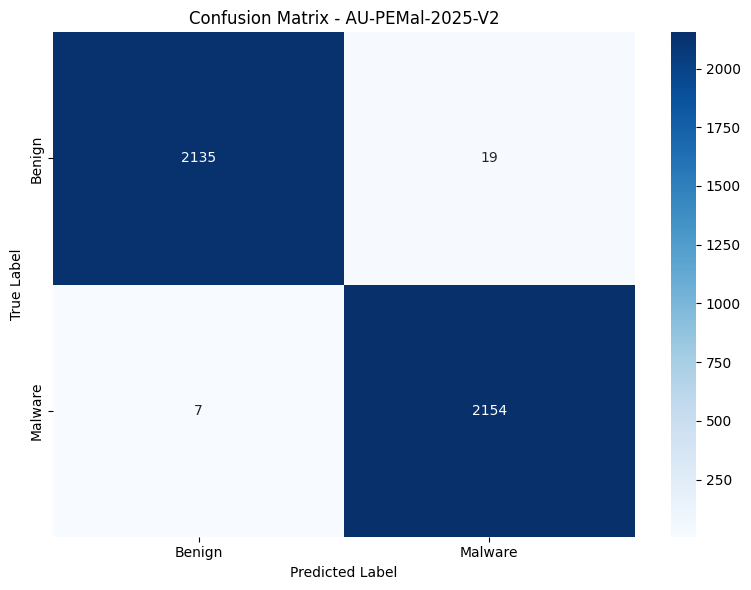

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

input_file = "AU-PEMal-2025-V2.csv"
output_file = "AU-PEMal-2025-V2_Cleaned.csv"

# ---------------------------------------------------------
# 1. File Upload / Existence Check
# ---------------------------------------------------------
if not os.path.exists(input_file):
    try:
        from google.colab import files

        print(f"Please upload '{input_file}':")
        uploaded = files.upload()
    except ImportError:
        pass

# ---------------------------------------------------------
# 2. Data Cleaning & Hex Conversion
# ---------------------------------------------------------
df = pd.read_csv(input_file)
print(f"Initial Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Drop non-predictive identifier columns
non_feature_cols = ["sha1", "Name", "filename", "Raw_filename", "hash", "md5"]
cols_to_drop = [c for c in non_feature_cols if c in df.columns]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print(f"Dropped non-predictive hash/identifier columns: {cols_to_drop}")

# Convert PE Header Hexadecimal columns ('0x...') to numeric integers
hex_cols = [
    "EntryPoint",
    "SizeOfCode",
    "SizeOfImage",
    "SizeOfInitializedData",
    "SizeOfUninitializedData",
    "rdata_VirtualSize",
    "rdata_VirtualAddress",
    "rdata_SizeOfRawData",
    "rdata_PointerToRawData",
    "text_VirtualSize",
    "text_SizeOfRawData",
    "text_PointerToRawData",
    "BaseOfCode",
    "BaseOfData",
    "ImageBase",
    "Checksum",
    "SectionAlignment",
    "SizeOfHeaders",
]


def parse_hex_to_int(val):
    if pd.isna(val):
        return 0
    val_str = str(val).strip()
    try:
        if val_str.lower().startswith("0x"):
            return int(val_str, 16)
        else:
            return int(float(val_str))
    except Exception:
        return 0


for col in hex_cols:
    if col in df.columns:
        df[col] = df[col].apply(parse_hex_to_int)

# Drop missing values and duplicates
df = df.dropna()
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    print(f"Dropping {duplicate_count} duplicate feature rows...")
    df = df.drop_duplicates(keep="first")

# ---------------------------------------------------------
# 3. Target Identification & Feature Extraction
# ---------------------------------------------------------
# Detect target variable name automatically
possible_targets = [
    "Class",
    "Label",
    "label",
    "class",
    "Category",
    "category",
    "target",
    "Type",
]
target_col = next((c for c in possible_targets if c in df.columns), df.columns[-1])
print(f"Target Column identified: '{target_col}'")

X = df.drop(columns=[target_col])
y = df[target_col]

# Restrict features to numeric values
X = X.select_dtypes(include=[np.number])

# Drop zero-variance constant columns
constant_cols = [c for c in X.columns if X[c].nunique() <= 1]
if constant_cols:
    print(
        f"Dropping zero-variance constant columns ({len(constant_cols)}): {constant_cols}"
    )
    X = X.drop(columns=constant_cols)

# Export cleaned dataset
df_cleaned = pd.concat([X, y], axis=1)
print(
    f"Final Cleaned Shape: {df_cleaned.shape[0]} rows, {df_cleaned.shape[1]} columns"
)
df_cleaned.to_csv(output_file, index=False)

try:
    from google.colab import files

    files.download(output_file)
except Exception:
    pass

# ---------------------------------------------------------
# 4. Target Encoding, Train/Test Split & Scaling
# ---------------------------------------------------------
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------------
# 5. Model Training (Random Forest)
# ---------------------------------------------------------
print("\n--- Training Random Forest Classifier ---")
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train_scaled, y_train)

# ---------------------------------------------------------
# 6. Performance Evaluation & Confusion Matrix
# ---------------------------------------------------------
y_pred = clf.predict(X_test_scaled)

print("\n================ Performance Metrics ================")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(
    classification_report(
        y_test, y_pred, target_names=[str(c) for c in label_encoder.classes_]
    )
)

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.title("Confusion Matrix - AU-PEMal-2025-V2")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()